# Risk Analyzer: Identifying Risks to European Countries

## Why It Matters


## What It Does
The `RiskAnalyzer` class, part of the bigdata-research-tools package, is purpose-built to meet this challenge. Designed for risk analysts, portfolio managers, and investment professionals, it systematically analyzes corporate exposure to specific risk channels using unstructured data from news, earnings calls, and regulatory filings.

## How It Works
RiskAnalyzer combines **hybrid semantic search**, **risk factor taxonomies**, and **structured validation techniques** to deliver:

- **Targeted extraction of risk signals** and supporting evidence from massive unstructured datasets
- **Standardized exposure metrics** to compare risk across firms, sectors, or portfolios
- **Actionable insights** that inform investment strategies and enterprise risk decisions
- **Time-based monitoring** to track how exposure levels shift in response to world events

## A Real-World Use Case


## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [3]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Import Required Libraries

In [4]:
from bigdata_client import Bigdata
from bigdata_client.models.search import DocumentType
import sys
import os
import pandas as pd
from bigdata_client.query import SentimentRange

# Bigdata Research Tools imports
from bigdata_research_tools.workflows.risk_analyzer import RiskAnalyzer
from bigdata_research_tools.workflows.utils import get_scored_df
from src.search_entities import search_by_entities, post_process_dataframe
from src.entity_risk_prompt_labeler import (generate_risk_tree, get_entity_risk_prompt,
                                            get_risk_entity_labeler_prompt, label_search_results)

In [5]:
from bigdata_research_tools.labeler.risk_labeler import RiskLabeler

## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [6]:
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")

✅ Plotly configured for Jupyter/VS Code


## Define Output Paths

We define the output paths for our thematic screening results.

In [7]:
# Define output file paths for our report
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

export_path = f"{output_dir}/risk_analyzer_countries_results.xlsx"

## Load Credentials

In [8]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
#load_dotenv(script_dir / '.env')
load_dotenv('/home/abouchs/.python_env_var/.env')

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


In [9]:
os.environ["BIGDATA_OTHER_ENTITY_PLACEHOLDER"] = "Other Entity"
os.environ["BIGDATA_TARGET_ENTITY_PLACEHOLDER"] = "Target Entity"

## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [10]:
bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

## Defining Your Risk Analysis Parameters

To perform a portfolio risk analysis, we need to define several key parameters:

- **Main Theme** (`main_theme`): The risk scenario to analyze (e.g. US Import Tariffs against China)
- **Focus** (`focus`): The analyst focus that provides an expert perspective on the scenario and helps break it down into risks
-  **Entity Universe** (``entities``): The set of entities to screen
-  **Control Entities** (``control_entities``): The set of entities to be always comentioned with your watchlist (e.g. people, places, organizations, etc)
-  **Time Period** (``start_date`` and ``end_date``): The date range over which to
   run the search
-  **Document Type** (``document_type``): Specify which documents to search over
   (transcripts, filings, news)
-  **Sources** (``sources``): Specify set of sources within a document type, for
   example which news outlets (available via Bigdata API) you wish to
   search over
-  **Fiscal Year** (``fiscal_year``): If the document type is transcripts or
   filings, fiscal year needs to be specified
-  **Model Selection** (``llm_model``): The LLM model used to mindmap the theme
   and label the search result chunks
-  **Rerank Threshold** (``rerank_threshold``): By setting this value, you’re
   enabling the cross-encoder which reranks the results and selects
   those whose relevance is above the percentile you specify (0.7 being
   the 70th percentile). More information on the re-ranker can be found
   [here](https://sdk.bigdata.com/en/latest/how_to_guides/rerank_search.html).
- **Sentiment Range** (``sentiment_range``): The range for chunk sentiment (needs to be a SentimentRange object)
-  **Focus** (``focus``): Specify a focus within the main theme. This will then
   be used in building the LLM generated mindmapper

In [11]:
# ===== Theme Definition =====
main_theme = "Spillovers from Rising Bond Spreads in Western Europe"
analyst_focus="Generate a mind map of current and future risks that western european countries can face as a result of rising bond spreads."

# ===== Entity Universe =====
entity_names = [
    "Germany", "France", "Italy", "Spain", "Netherlands", "Belgium", "Austria",
    "Portugal", "Greece", "Ireland",
]

entities = [bigdata.knowledge_graph.autosuggest(entity_name, limit=1)[0] for entity_name in entity_names]
control_entities = None #or {'place': ['Euro Area', 'Eurozone'], 'orga': ['European Central Bank']}

# ===== LLM Specification =====
llm_model = "openai::gpt-4o-mini"

# ===== Docs Configuration =====
document_type = DocumentType.NEWS
fiscal_year = None

# ===== Enable/Disable Reranker =====
rerank_threshold = None

# ===== Enable/Disable Sentiment Range =====
sentiment_range = None

# ===== Specify Time Range =====
start_date = "2025-07-01"
end_date = "2025-10-03"

In [12]:
entities

[Place(id='E96159', name='Germany', volume=None, description='The Federal Republic of Germany is a country located in central Europe.', entity_type='PLCE', place_type='Country', country='Germany', region=None),
 Place(id='C3FAF4', name='France', volume=None, description='The French Republic is a country located in Western Europe.', entity_type='PLCE', place_type='Country', country='France', region=None),
 Place(id='847BDC', name='Italy', volume=None, description='The Italian Republic is a country located in southern Europe.', entity_type='PLCE', place_type='Country', country='Italy', region=None),
 Place(id='986F1A', name='Spain', volume=None, description='The Kingdom of Spain is a country located in southwestern Europe on the Iberian Peninsula.', entity_type='PLCE', place_type='Country', country='Spain', region=None),
 Place(id='A20475', name='The Netherlands', volume=None, description='The Kingdom of the Netherlands is a country located in Northwestern Europe.', entity_type='PLCE', p

## Mindmap a Theme Taxonomy with Bigdata Research Tools

You can leverage Bigdata Research Tools to generate a comprehensive theme taxonomy with an LLM, breaking down a megatrend into smaller,
well-defined concepts for more targeted analysis.

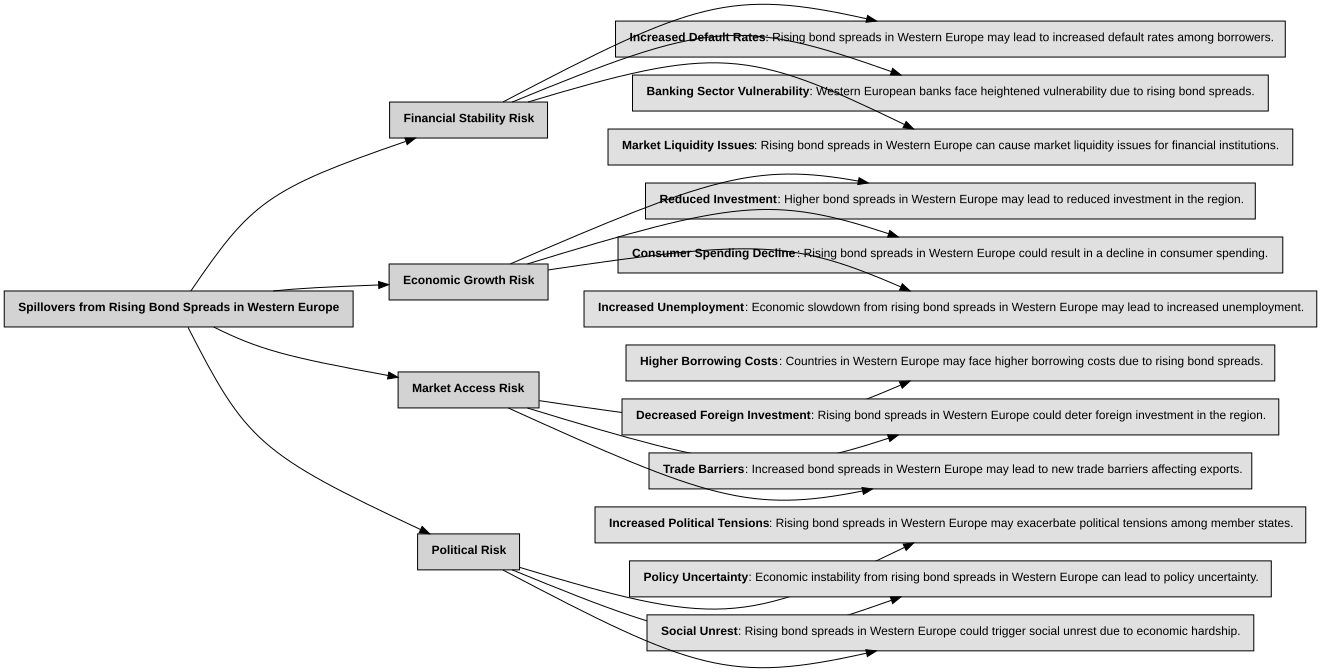

In [13]:
theme_tree = generate_risk_tree(
    main_theme=main_theme,
    analyst_focus=analyst_focus,
    system_prompt=get_entity_risk_prompt(main_theme, analyst_focus),
)

theme_tree.visualize()

The taxonomy tree includes descriptive sentences that explicitly connect each sub-theme back to the main theme, ensuring all search results remain contextually relevant to our central trend.

In [14]:
node_summaries = list(theme_tree.get_terminal_label_summaries().values())
labels = list(theme_tree.get_terminal_label_summaries().keys())

In [15]:
node_summaries

['Rising bond spreads in Western Europe may lead to increased default rates among borrowers.',
 'Western European banks face heightened vulnerability due to rising bond spreads.',
 'Rising bond spreads in Western Europe can cause market liquidity issues for financial institutions.',
 'Higher bond spreads in Western Europe may lead to reduced investment in the region.',
 'Rising bond spreads in Western Europe could result in a decline in consumer spending.',
 'Economic slowdown from rising bond spreads in Western Europe may lead to increased unemployment.',
 'Countries in Western Europe may face higher borrowing costs due to rising bond spreads.',
 'Rising bond spreads in Western Europe could deter foreign investment in the region.',
 'Increased bond spreads in Western Europe may lead to new trade barriers affecting exports.',
 'Rising bond spreads in Western Europe may exacerbate political tensions among member states.',
 'Economic instability from rising bond spreads in Western Europe

## Retrieve Content using Bigdata’s Search Capabilities

With the theme taxonomy and screening parameters, you can leverage the
Bigdata API to run a search on news or company transcripts. We need to define 3
more parameters for searching:

-  **Frequency** (``freq``): The frequency of the date ranges to search over.
   Supported values:

   -  `Y`: Yearly intervals.
   -  `M`: Monthly intervals.
   -  `W`: Weekly intervals.
   -  `D`: Daily intervals. Defaults to `3M`.

-  **Document Limit** (``document_limit``): The maximum number of documents to
   return per query to Bigdata API.
-  **Batch Size** (``batch_size``): The number of entities to include in a
   single batched query.

In [16]:
freq = "3M"
document_limit = 10
batch_size = 10

In [17]:
df_sentences = search_by_entities(entities=entities,
    sentences=node_summaries,
    start_date=start_date,
    end_date=end_date,
    scope=document_type,
    control_entities=control_entities,
    sources=None,
    fiscal_year=None,
    freq=freq,
    document_limit=document_limit,
    batch_size=batch_size
)

Running 24 searches (12 queries over 2 date ranges)
Example query:
And(Similarity('Western European banks face heightened vulnerability due to rising bond spreads.'), Or(Entity('E96159'), Place(id='C3FAF4', name='France', volume=None, description='The French Republic is a country located in Western Europe.', entity_type='PLCE', place_type='Country', country='France', region=None), Place(id='847BDC', name='Italy', volume=None, description='The Italian Republic is a country located in southern Europe.', entity_type='PLCE', place_type='Country', country='Italy', region=None), Place(id='986F1A', name='Spain', volume=None, description='The Kingdom of Spain is a country located in southwestern Europe on the Iberian Peninsula.', entity_type='PLCE', place_type='Country', country='Spain', region=None), Place(id='A20475', name='The Netherlands', volume=None, description='The Kingdom of the Netherlands is a country located in Northwestern Europe.', entity_type='PLCE', place_type='Country', countr

Processing news results...: 100%|██████████| 240/240 [00:00<00:00, 19811.32it/s]


## Label the Results

Use an LLM to analyze each text chunk and determine its relevance to the sub-themes. Any chunks which aren't explicitly linked to our main theme will be filtered out.

In [18]:
labels

['Increased Default Rates',
 'Banking Sector Vulnerability',
 'Market Liquidity Issues',
 'Reduced Investment',
 'Consumer Spending Decline',
 'Increased Unemployment',
 'Higher Borrowing Costs',
 'Decreased Foreign Investment',
 'Trade Barriers',
 'Increased Political Tensions',
 'Policy Uncertainty',
 'Social Unrest']

In [23]:
labels

['Increased Default Rates',
 'Banking Sector Vulnerability',
 'Market Liquidity Issues',
 'Reduced Investment',
 'Consumer Spending Decline',
 'Increased Unemployment',
 'Higher Borrowing Costs',
 'Decreased Foreign Investment',
 'Trade Barriers',
 'Increased Political Tensions',
 'Policy Uncertainty',
 'Social Unrest']

In [25]:
labeler = RiskLabeler(llm_model=llm_model, label_prompt=get_risk_entity_labeler_prompt(main_theme, labels).strip())
df, df_labels = label_search_results(
        df_sentences = df_sentences,
        terminal_labels = labels,
        risk_tree = theme_tree,
        labeler = labeler,
        additional_prompt_fields = ['headline'],
        main_theme = main_theme,)

Querying an LLM...:   0%|          | 0/430 [00:00<?, ?it/s]

Querying an LLM...: 100%|██████████| 430/430 [00:22<00:00, 19.42it/s]


## Assess Thematic Exposure Across Your Entities

We’ll look at the top 10 most exposed companies to our main theme. The function `get_scored_df` will calculate the composite
thematic score, summing up the scores across the sub-themes for each
entity (`df_entity`).

In [26]:
df_entity = pd.DataFrame()

df_entity = get_scored_df(
    df_labels, index_columns=["Entity", "Country"], pivot_column="Sub-Scenario"
)

In [27]:
df_labels

,Time Period,Date,Entity,Country,Document ID,Headline,Quote,Motivation,Sub-Scenario,Other Entities,Other Entities IDs,Other Entities Types,Risk Channel,Risk Factor,Highlights
0,Oct 2025,2025-10-02,Austria,Austria,4289B0899E38DACAB0C6FDCC7BB83309,Europe has the Capabilities but Lacks Politica...,Some of the current populist movements have re...,The text mentions Austria in the context of pr...,Increased Political Tensions,"[Germany, Italy, France]","[E96159, 847BDC, C3FAF4]","[PLCE, PLCE, PLCE]",Political Risk/Increased Political Tensions,Political Risk,"[FPO in Austria, pro-Russian European parties ..."
1,Oct 2025,2025-10-01,Belgium,Belgium,8C15787582C54DEA41C2F10E8E5561AB,EU leaders plot defense boost in shadow of Den...,Leaders will pick over a proposal from Brussel...,Belgium is facing potential resistance regardi...,Policy Uncertainty,[],[],[],Political Risk/Policy Uncertainty,Political Risk,[it is seen as crucial to help Kiev plug loomi...
2,Oct 2025,2025-10-01,Belgium,Belgium,A63578A49F42B8DC204251F143A1C824,The Irish Times view on the EU summit: Europe'...,The meeting was also the first opportunity for...,Belgium is concerned that the seizure of Russi...,Banking Sector Vulnerability,[France],[C3FAF4],[PLCE],Financial Stability Risk/Banking Sector Vulner...,Financial Stability Risk,"[Belgium are wary, however, that the seizure o..."
3,Oct 2025,2025-10-02,Belgium,Belgium,35EFEE0259BFA2FEE628E0E3C3EF9ECD,Belgium seeks guarantees over risks of using f...,'If Europe alone bears financial burden of sup...,Belgium's Prime Minister emphasizes the need f...,Policy Uncertainty,[],[],[],Political Risk/Policy Uncertainty,Political Risk,[risks from the use of frozen Russian assets a...
4,Oct 2025,2025-10-02,Belgium,Belgium,53D0E34B8ECB878A431EFAA81F931CA8,EU Leaders Weigh Plan to Tap Frozen Russian As...,The European Commission's proposal would chann...,Belgium is raising concerns about the legal an...,Policy Uncertainty,"[The Netherlands, France]","[A20475, C3FAF4]","[PLCE, PLCE]",Political Risk/Policy Uncertainty,Political Risk,"[Belgium, France, and Luxembourg raised legal ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Oct 2025,2025-10-03,Spain,Spain,86CBB4DB4BECC3154ED63F75CF63D8E4,"Global Economy Briefing for October 2, 2025",Venezuela climbed to 0.95 million. Nigeria sli...,The text indicates that Spain is involved in b...,Higher Borrowing Costs,[France],[C3FAF4],[PLCE],Market Access Risk/Higher Borrowing Costs,Market Access Risk,"[Borrowing costs kept rising in Europe., Spain..."
166,Sep 2025,2025-09-01,The Netherlands,The Netherlands,C58D63EEEE8C4EE6037FF35BBD4ACDA5,India suffers worst bond selloff since 2022 as...,"That, plus strong dollar demand from importers...",The text indicates that The Netherlands's bond...,Higher Borrowing Costs,"[France, Germany, Germany]","[C3FAF4, E96159, E96159]","[PLCE, PLCE, PLCE]",Market Access Risk/Higher Borrowing Costs,Market Access Risk,[Yields in France and The Netherlands moved in...
167,Oct 2025,2025-10-02,The Netherlands,The Netherlands,53D0E34B8ECB878A431EFAA81F931CA8,EU Leaders Weigh Plan to Tap Frozen Russian As...,The European Commission's proposal would chann...,The Netherlands supports the proposal to chann...,Policy Uncertainty,"[France, Belgium]","[C3FAF4, 5A4EFD]","[PLCE, PLCE]",Political Risk/Policy Uncertainty,Political Risk,"[Supporters, including Denmark, Sweden, and Th..."
168,Oct 2025,2025-10-03,The Netherlands,The Netherlands,4178BCAF9D6B236EF2A4984C6914ADBA,"European Union's Slabs, Billets and Blooms Mar...",Exports from Germany increased at an average a...,The Netherlands is experiencing a downward tre...,Higher Borrowing Costs,"[Germany, Germany, Spain, Spain, Italy, France...","[E96159, E96159, 986F1A, 986F1A, 847BDC, C3FAF...","[PLCE, PLCE, PLCE, PLCE, PLCE, PLCE, PLCE]",Market Access Risk/Higher Borrowing Costs,Market Access Risk,[The Netherlands (-6.7%) illustrated a downwar...


Displaying Entity Risk Exposure Dashboard...

Entity Risk Exposure Heatmap (Raw Scores):

Total Entity Risk Exposure Score:

Top Risk Exposures by Entity:

Risk Exposure Scores across Sub-Scenarios:


/home/abouchs/git/bigdata-cookbook/Screener_for_Entities/src/visualization_tool.py:736: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



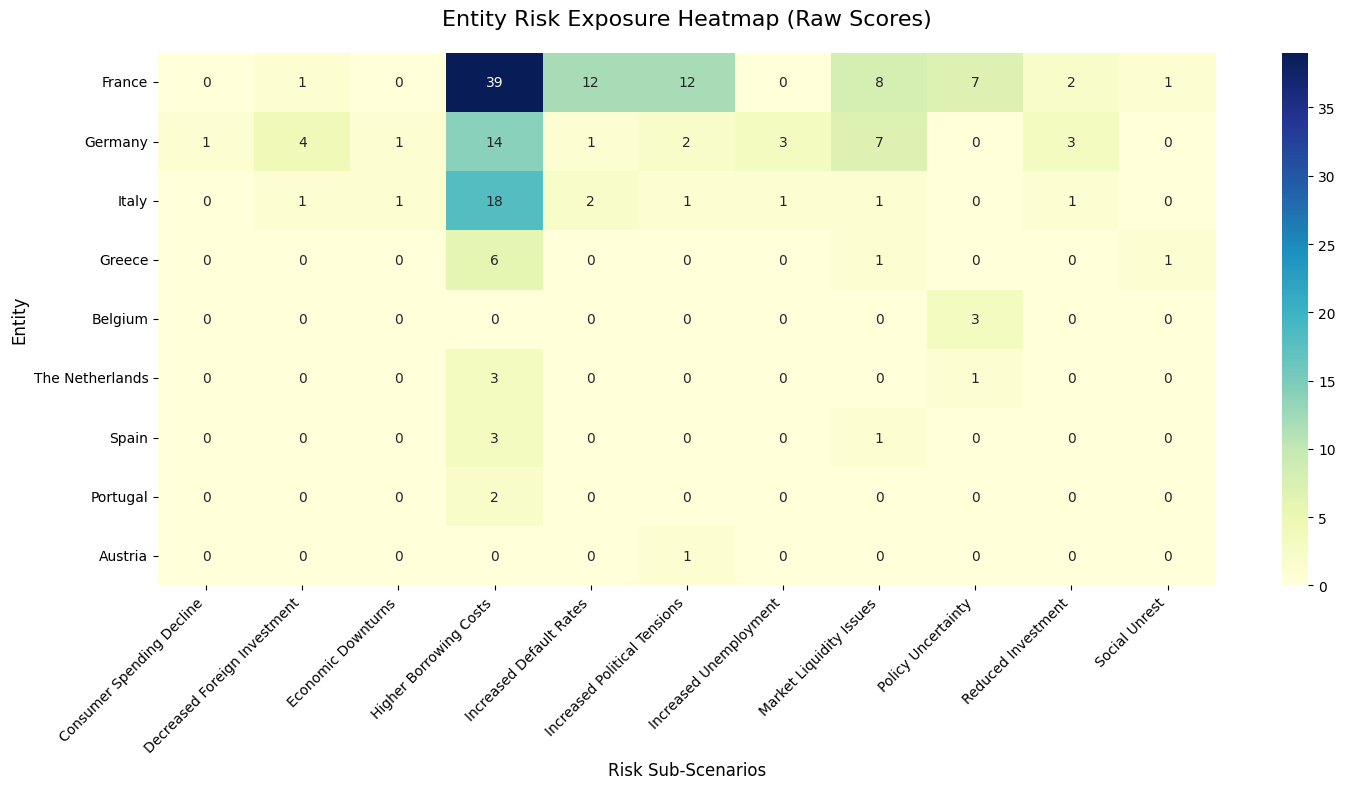

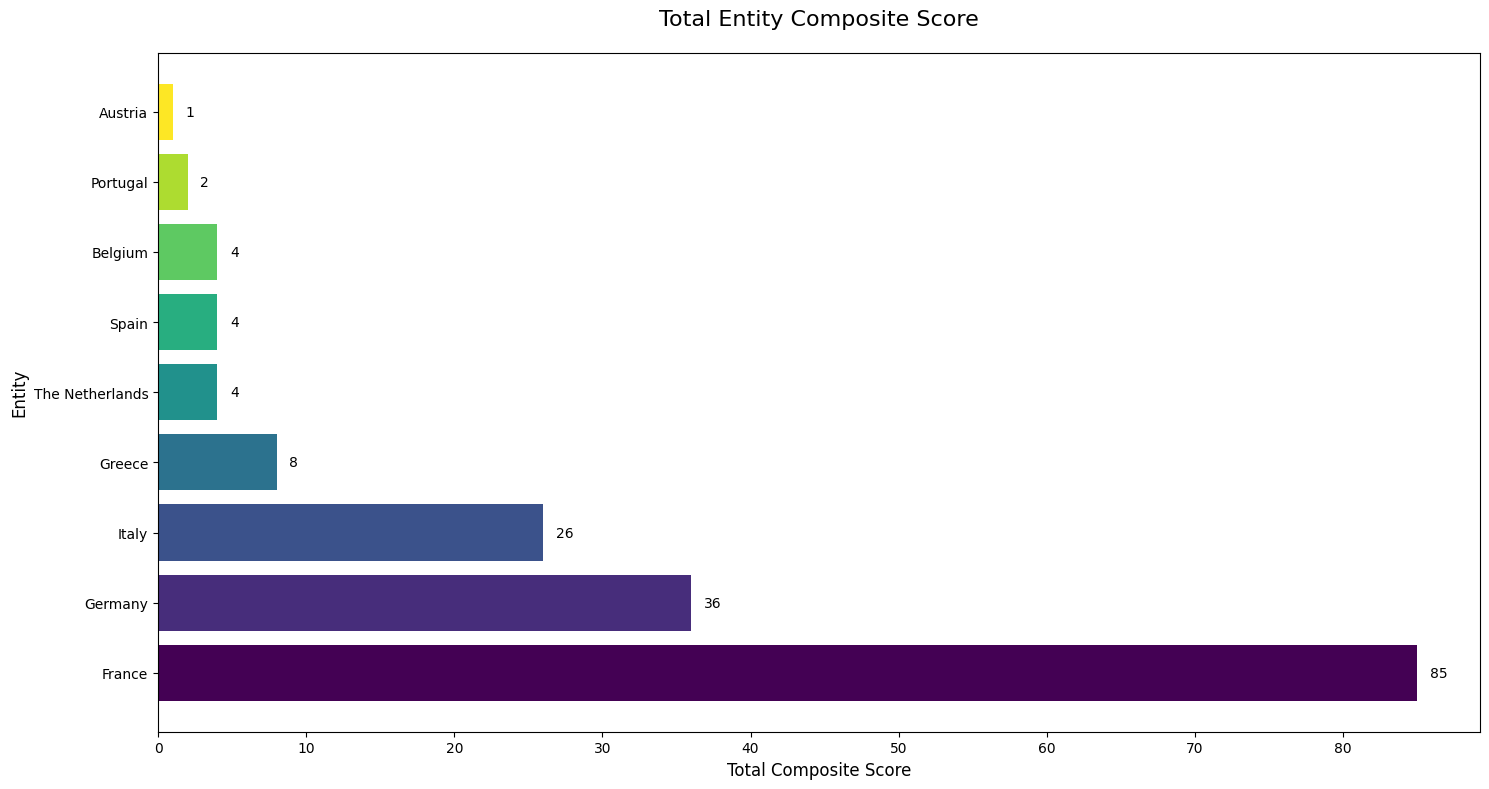

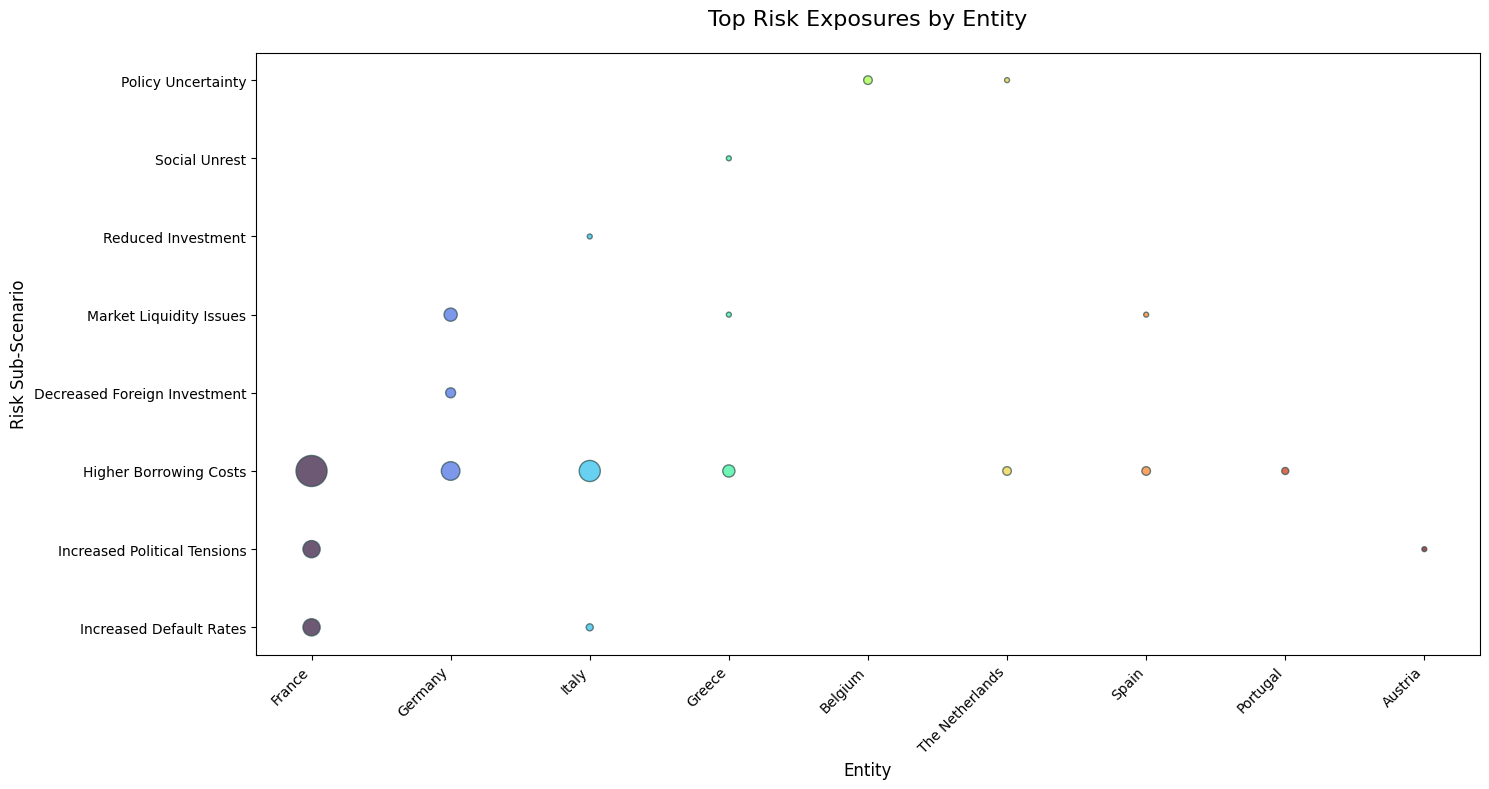

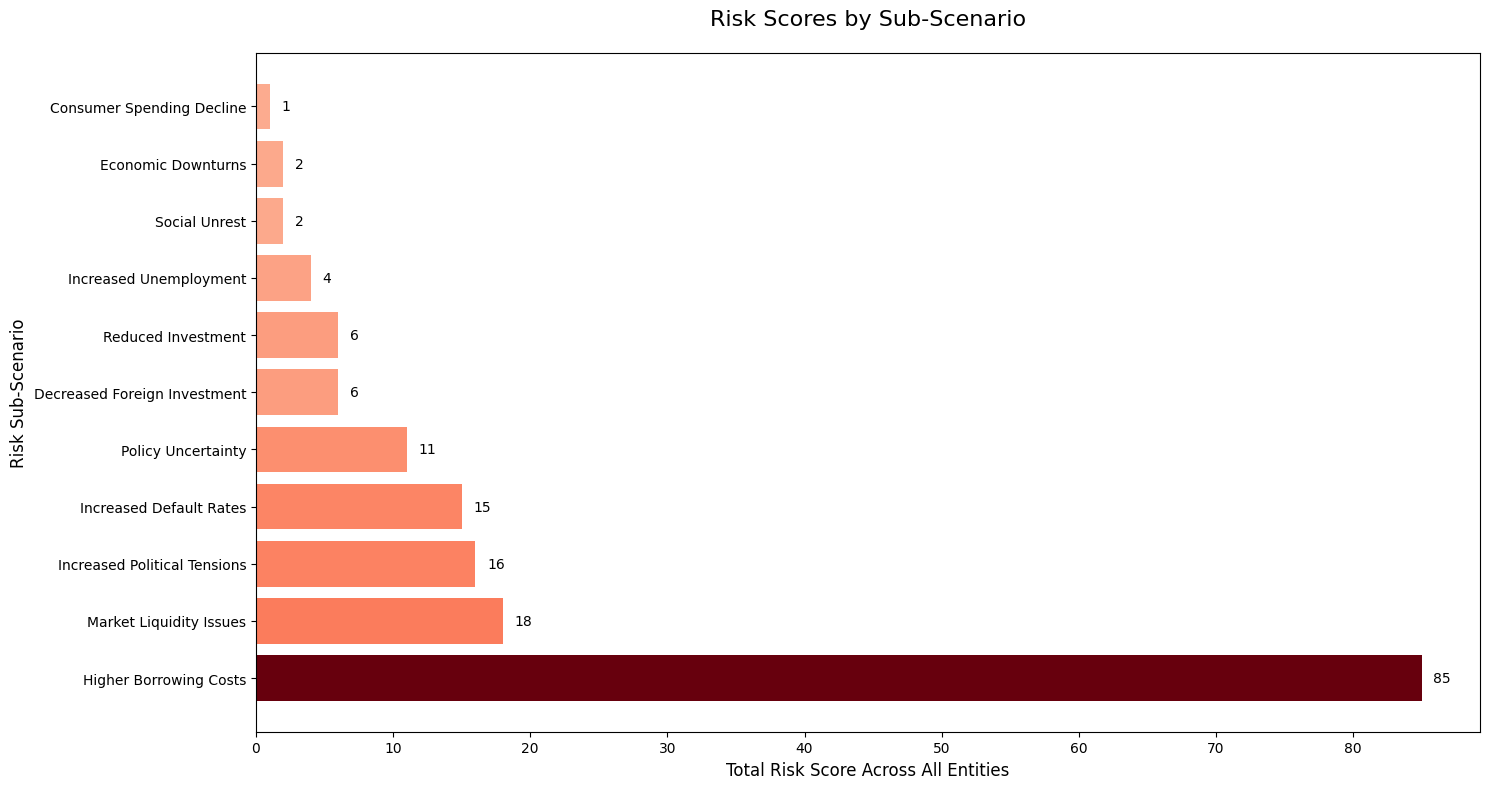

In [30]:
from src.visualization_tool import display_risk_figures_cookbooks

display_risk_figures_cookbooks(df_entity, interactive=False, n_entities=10)